In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [21]:
img = cv2.imread('/content/dragon.jpeg',0)

In [22]:
img_array = np.array(img)
print("Image Shape:", img_array.shape)


Image Shape: (1066, 1600)


In [23]:
sp = img.copy().astype(np.float32)
prob = 0.02
rand = np.random.rand(*img.shape)
sp[rand < prob] = 0          # Pepper → Black
sp[rand > 1 - prob] = 255    # Salt   → White

sp = sp.astype(np.uint8)


In [24]:
def median_filter(image, kernel_size=3):
    pad = kernel_size // 2
    h, w = image.shape
    padded = np.pad(image, pad, mode='constant', constant_values=0)
    output = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            # Extract window
            window = padded[i:i+kernel_size, j:j+kernel_size]

            # Flatten and sort
            sorted_values = np.sort(window.flatten())

            # Find median (middle value)
            median_index = len(sorted_values) // 2
            median_value = sorted_values[median_index]

            # Replace center pixel with median
            output[i][j] = median_value

    return output

filtered_img = median_filter(sp, kernel_size=3)


In [25]:
os.makedirs(r'D:\IPCV\LAB-EXP-5\resultant_img', exist_ok=True)
cv2.imwrite(r'D:\IPCV\LAB-EXP-5\resultant_img\noisy.jpeg',   sp)
cv2.imwrite(r'D:\IPCV\LAB-EXP-5\resultant_img\filtered.jpeg', filtered_img)
print("Images saved to resultant_img folder!")

Images saved to resultant_img folder!


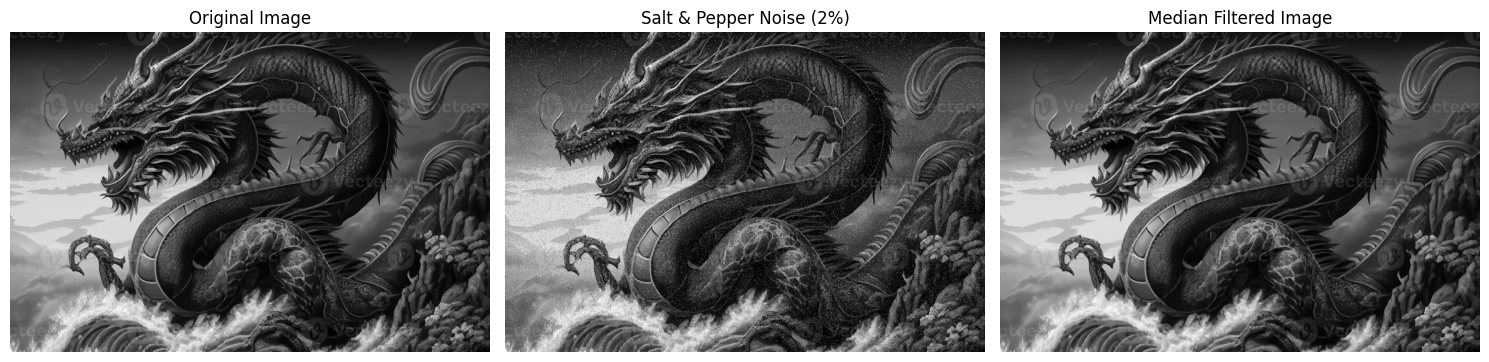

Done!


In [26]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_array, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sp, cmap='gray')
plt.title('Salt & Pepper Noise (2%)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered_img, cmap='gray')
plt.title('Median Filtered Image')
plt.axis('off')

plt.tight_layout()
plt.savefig(r'D:\IPCV\LAB-EXP-5\resultant_img\comparison.jpeg')
plt.show()

print("Done!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')